# testing myself

In [107]:
import torch
import random
import torch.nn.functional as F

In [108]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [109]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [110]:
# levers
box_size = 4
embedding_dim = 20
W1_dim = 100
epochs = 40000

In [111]:
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * box_size
        for ch in w + '.':
            ix = stoi[ch]
            Y.append(ix)
            X.append(context)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(f"Shape X: {X.shape}, Shape Y: {Y.shape}")
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[:n2-n1])
X_test, Y_test = build_dataset(words[n2:])

Shape X: torch.Size([182625, 4]), Shape Y: torch.Size([182625])
Shape X: torch.Size([22903, 4]), Shape Y: torch.Size([22903])
Shape X: torch.Size([22866, 4]), Shape Y: torch.Size([22866])


In [112]:
# training params
g = torch.Generator().manual_seed(5)
C = torch.randn(len(stoi), embedding_dim, generator=g)
W1 = torch.randn(box_size * embedding_dim, W1_dim, generator=g)
b1 = torch.randn(W1_dim, generator=g)
W2 = torch.randn(W1_dim, len(stoi), generator=g)
b2 = torch.randn(len(stoi), generator=g)
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters)  # number of parameters

11367

In [113]:
print(f"Shape of W1 = {W1.shape}")
print(f"Shape of b1 = {b1.shape}")
print(f"Shape of W2 = {W2.shape}")
print(f"Shape of b2 = {b2.shape}")

Shape of W1 = torch.Size([80, 100])
Shape of b1 = torch.Size([100])
Shape of W2 = torch.Size([100, 27])
Shape of b2 = torch.Size([27])


In [114]:
for p in parameters:
    p.requires_grad = True

lre = torch.linspace(-3,0,epochs)
lrs = 10 ** lre

lossi = []
stepi = []

In [119]:
# training loop
for i in range(epochs):
    ix = torch.randint(0, X_train.shape[0], size = (32,), generator = g)
    emb = C[X_train[ix]]
    h = torch.tanh(emb.view(-1,int(W1.shape[0])) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_train[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    lr = 0.1

    for p in parameters:
        p.data += -lr * p.grad
    
    lossi.append(loss.log10().item())
    stepi.append(i)
print(loss)

tensor(2.1732, grad_fn=<NllLossBackward0>)


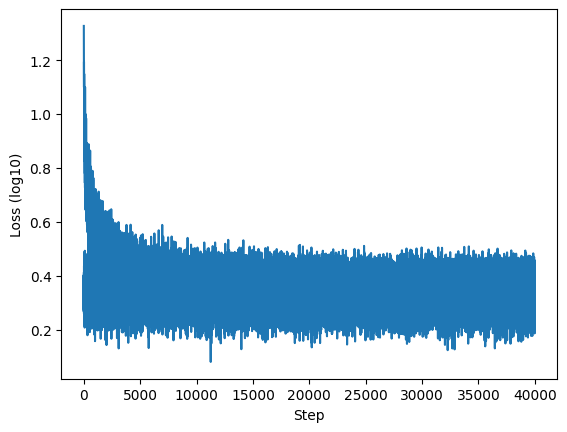

In [120]:
# plot loss vs step
import matplotlib.pyplot as plt
plt.plot(stepi, lossi)
plt.xlabel('Step')
plt.ylabel('Loss (log10)')
plt.show()

In [121]:
# evaluate on test set
emb = C[X_test]
h = torch.tanh(emb.view(-1,int(W1.shape[0])) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_test)
print(f"Test loss: {loss.item()}")

Test loss: 2.1934211254119873


In [125]:
# generate 10 names
for _ in range(20):
    out = []
    context = [0] * box_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1,int(W1.shape[0])) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

dena.
ellah.
kemlachella.
ameh.
azetyah.
gamon.
shorsetty.
brexlias.
kennanson.
semiyah.
esmay.
dyel.
kaise.
till.
mavry.
asaser.
kahionen.
maes.
gabri.
raiilai.


In [143]:
# try 2
words = open('names.txt', 'r').read().splitlines()

In [144]:
chars = sorted(set(''.join(words)))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [149]:
# build dataset
def build_dataset(words):
    X, Y = [], []
    block_size = 4

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(f"Shape X: {X.shape}, Shape Y: {Y.shape}")
    return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

Shape X: torch.Size([182441, 4]), Shape Y: torch.Size([182441])
Shape X: torch.Size([22902, 4]), Shape Y: torch.Size([22902])
Shape X: torch.Size([22803, 4]), Shape Y: torch.Size([22803])
